# <span style=" font-family: Calibri" > **Electoral Contention: Random Forest**

### <span style=" font-family: Calibri" > *Maya Dalton (4/2026)*
---

## Set Up

In [3]:
# Installing packages
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
import tensorflow as tf
import sklearn
import warnings
import random
import shap
warnings.filterwarnings('ignore')

## Random Forest and Logit
from pathlib import Path
from sklearn.model_selection import (StratifiedKFold, train_test_split, 
                                    cross_val_score, learning_curve, 
                                    validation_curve, RandomizedSearchCV)
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.inspection import (permutation_importance, PartialDependenceDisplay, partial_dependence)
from sklearn.metrics import (roc_auc_score, average_precision_score, auc,
                              precision_recall_curve, roc_curve,
                              classification_report, confusion_matrix, accuracy_score)
from scipy.stats import loguniform, randint, uniform

## Neural Network
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import History
from scikeras.wrappers import KerasClassifier

warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42); tf.random.set_seed(42)

## directory/file paths
base = Path.home() / "/Users/mdalton/Library/CloudStorage/OneDrive-ThePennsylvaniaStateUniversity"
path = base / "Dissertation" / "(1) EV Strategies" / "data" / "df_civilians.csv"

# ── outer CV splitter (same for all models) ──────────────────────────────────
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [4]:
# Load in and clean dataset
data = pd.read_csv(path)

# Drop unneeded columns
civ_data = data.drop(columns=['ActorNameNew','ActorTypeNew','country','year'])
#print(civ_data)

In [5]:
# Define Xs and Y
X = civ_data.drop('elect_vio', axis=1)  #Means that the x variable is everything in the EMP dataset except attrition
y = civ_data['elect_vio'] # The dependent variable is attrition

# Scaling predictors & test/train split
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns= X.columns)

X_train, X_test, y_train, y_test = train_test_split( # separate out test data for hyp tuning (3 datasets)! 
    X_scaled_df, y, test_size=0.3, random_state = 42) 

In [6]:
pd.Series(y).value_counts()

elect_vio
1    942
0    837
Name: count, dtype: int64

## Random Forest

### Hyperparameter Tuning & Fitting the Model

In [9]:
# Step 1: Define the model
rf = RandomForestClassifier(
    random_state=1,
    n_jobs=-1
)

# Step 2: Define parameter distributions
rf_param_dist = {
    'n_estimators': randint(200, 1200),
    'max_depth': [None] + list(range(5, 41, 5)),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 15),
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
}

# Step 3: Randomized search and fit model
rf_inner = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_dist,
    n_iter=50, 
    scoring='accuracy', 
    cv=10,
    random_state=1, 
    refit=True, 
    n_jobs=-1, 
    verbose=0,
)

rf_nested_scores_acc  = []
rf_nested_scores_auc  = []
rf_nested_scores_aupr = []
 
for train_idx, test_idx in outer_cv.split(X_scaled_df, y):
    X_tr, X_te = X_scaled_df.iloc[train_idx], X_scaled_df.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx],            y.iloc[test_idx]
    rf_inner.fit(X_tr, y_tr)
    best = rf_inner.best_estimator_
    y_prob = best.predict_proba(X_te)[:, 1]
    y_pred = best.predict(X_te)
    rf_nested_scores_acc.append((y_pred == y_te).mean())
    rf_nested_scores_auc.append(roc_auc_score(y_te, y_prob))
    rf_nested_scores_aupr.append(average_precision_score(y_te, y_prob))

## Output
#print("Best CV score:", rs.best_score_) #Best CV score: 0.747
#print("Best parameters:", rs.best_params_)
# Best parameters: {'bootstrap': True, 'max_depth': None, 'max_features': None, 'min_samples_leaf': 8, 
# 'min_samples_split': 18, 'n_estimators': 475}

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check i

In [10]:
print("=== Random Forest – nested 5-fold outer CV ===")
print(f"Accuracy : {np.mean(rf_nested_scores_acc):.3f} ± {np.std(rf_nested_scores_acc):.3f}")
print(f"ROC-AUC  : {np.mean(rf_nested_scores_auc):.3f} ± {np.std(rf_nested_scores_auc):.3f}")
print(f"PR-AUC   : {np.mean(rf_nested_scores_aupr):.3f} ± {np.std(rf_nested_scores_aupr):.3f}")
print("Best parameters:", rf_inner.best_params_)

=== Random Forest – nested 5-fold outer CV ===
Accuracy : 0.741 ± 0.035
ROC-AUC  : 0.808 ± 0.029
PR-AUC   : 0.814 ± 0.025
Best parameters: {'bootstrap': True, 'max_depth': 35, 'max_features': None, 'min_samples_leaf': 11, 'min_samples_split': 2, 'n_estimators': 689}


### Assessing Performance

In [12]:
# Step 3: Predicted probabilities 
y_prob_rf  = rf_inner.best_estimator_.predict_proba(X_test)[:, 1]
y_pred = rf_inner.best_estimator_.predict(X_test)

# Step 4: Print Scores
best_idx = rf_inner.best_index_
mean_cv_acc = rf_inner.cv_results_['mean_test_score'][best_idx]
std_cv_acc  = rf_inner.cv_results_['std_test_score'][best_idx] # SD for accuracy

print(f'Accuracy: {mean_cv_acc:.3f} '
      f'+/- {std_cv_acc:.3f}')
print(classification_report(y_test, y_pred))

Accuracy: 0.744 +/- 0.041
              precision    recall  f1-score   support

           0       0.76      0.76      0.76       254
           1       0.78      0.79      0.78       280

    accuracy                           0.77       534
   macro avg       0.77      0.77      0.77       534
weighted avg       0.77      0.77      0.77       534



In [13]:
# Step 4: ROC and AUC
## ROC AUC
prec_rf,  rec_rf,  _ = precision_recall_curve(y_test, y_prob_rf)
aupr_rf = average_precision_score(y_test, y_prob_rf)

#fpr_rf, tpr_rf, thresholds = roc_curve(y_test, y_pred_prob)
#rf_roc_score = roc_auc_score(y_test, y_pred_prob)

print(f'Area under the PR curve: {aupr_rf:.3f}')

Area under the PR curve: 0.878


In [14]:
# Step 5: Calculate permutation importance & plot
best_rf = rf_inner.best_estimator_
perm_importance = permutation_importance(best_rf, X_test, y_test,
                                            n_repeats=30, random_state=1, n_jobs=-1)
feature_perm = perm_importance.importances_mean # Access the importance scores

# Step 7: Graphing most important features
sorted_importances_idx = perm_importance.importances_mean.argsort()
importances = pd.DataFrame(
    perm_importance.importances[sorted_importances_idx].T, 
    columns=X.columns[sorted_importances_idx],)

mean_importances_rf = importances.mean()  # Series: index=feature names, values=mean importance
mean_importances_rf = mean_importances_rf.sort_values()  # sort for nicer plotting

## Neural Network

### Hyperparameter Tuning & Model Fit

In [17]:
## Step 1: Define hyperparameter distributions
nn_param_dist = {
    'nn__epochs': randint(30, 100),
    'nn__batch_size': [16, 32, 64],
    'nn__optimizer__learning_rate': loguniform(1e-4, 1e-2)
}

## Step 2: Function to build NN model
def build_nn(input_dim=None, learning_rate=0.001):
    nn = Sequential([
        Dense(32, activation='relu', input_shape=(input_dim,)),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid'),
    ])
    nn.compile(optimizer=Adam(learning_rate=learning_rate),
                loss='binary_crossentropy', 
               metrics=['accuracy'])
    return nn

nn_nested_scores_acc  = []
nn_nested_scores_auc  = []
nn_nested_scores_aupr = []

## Step 3: Nested CV
for train_idx, test_idx in outer_cv.split(X_scaled_df, y):
    X_tr, X_te = X_scaled_df.iloc[train_idx], X_scaled_df.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx],            y.iloc[test_idx]
 
    nn_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('nn', KerasClassifier(
            model=build_nn,
            model__input_dim=X_tr.shape[1],
            verbose=0)),
    ])
    nn_inner = RandomizedSearchCV(
        nn_pipe, param_distributions=nn_param_dist,
        n_iter=20, scoring='accuracy', cv=5,
        random_state=42, n_jobs=-1, refit=True,
    )
    nn_inner.fit(X_tr, y_tr)
    y_prob = nn_inner.best_estimator_.predict_proba(X_te)[:, 1]
    y_pred = nn_inner.best_estimator_.predict(X_te)
    nn_nested_scores_acc.append((y_pred == y_te).mean())
    nn_nested_scores_auc.append(roc_auc_score(y_te, y_prob))
    nn_nested_scores_aupr.append(average_precision_score(y_te, y_prob))

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/comp

In [18]:
## Step 4: Print out results
print("\n=== Neural Network – nested 5-fold outer CV ===")
print(f"Accuracy : {np.mean(nn_nested_scores_acc):.3f} ± {np.std(nn_nested_scores_acc):.3f}")
print(f"ROC-AUC  : {np.mean(nn_nested_scores_auc):.3f} ± {np.std(nn_nested_scores_auc):.3f}")
print(f"PR-AUC   : {np.mean(nn_nested_scores_aupr):.3f} ± {np.std(nn_nested_scores_aupr):.3f}")
print("Best parameters:", nn_inner.best_params_)


=== Neural Network – nested 5-fold outer CV ===
Accuracy : 0.722 ± 0.029
ROC-AUC  : 0.792 ± 0.028
PR-AUC   : 0.791 ± 0.033
Best parameters: {'nn__batch_size': 32, 'nn__epochs': 65, 'nn__optimizer__learning_rate': 0.00023145798905204883}


### Assessing Performance

In [20]:
# Step 5: Predicted probabilities 
y_prob_nn  = nn_inner.best_estimator_.predict_proba(X_test)[:, 1]
y_pred = nn_inner.best_estimator_.predict(X_test)

# Step 6: Print Scores
best_idx = nn_inner.best_index_
mean_cv_acc = nn_inner.cv_results_['mean_test_score'][best_idx]
std_cv_acc  = nn_inner.cv_results_['std_test_score'][best_idx] # SD for accuracy

print(f'Accuracy: {mean_cv_acc:.3f} '
      f'+/- {std_cv_acc:.3f}')
print(classification_report(y_test, y_pred))

Accuracy: 0.713 +/- 0.031
              precision    recall  f1-score   support

           0       0.76      0.69      0.72       254
           1       0.74      0.81      0.77       280

    accuracy                           0.75       534
   macro avg       0.75      0.75      0.75       534
weighted avg       0.75      0.75      0.75       534



In [21]:
# Step 7: PR AUC
prec_nn,  rec_nn,  _ = precision_recall_curve(y_test, y_prob_nn)
aupr_nn = average_precision_score(y_test, y_prob_nn)

#fpr_nn, tpr_nn, thresholds_nn = roc_curve(y_test, y_pred_prob)
#nn_roc_score = roc_auc_score(y_test, y_pred_prob)

print(f'Area under the PR curve: {aupr_nn:.3f}')

Area under the PR curve: 0.848


In [22]:
# Step 8: Calculate permutation importance & plot
best_nn = nn_inner.best_estimator_
perm_importance = permutation_importance(best_nn, X_test, y_test,
                                            n_repeats=30, random_state=1, n_jobs=-1)
feature_perm = perm_importance.importances_mean # Access the importance scores

sorted_importances_idx = perm_importance.importances_mean.argsort()
importances = pd.DataFrame(
    perm_importance.importances[sorted_importances_idx].T, 
    columns=X.columns[sorted_importances_idx],)

mean_importances_nn = importances.mean()  # Series: index=feature names, values=mean importance
mean_importances_nn = mean_importances_nn.sort_values()  # sort for nicer plotting

### Training and Validation

In [24]:
# Step 9: Assessing Training and Validation Performances
# Impute missing values
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train.values.astype('float32'))
X_test_imputed = imputer.transform(X_test.values.astype('float32'))

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Build model manually 
nn_model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.1),
    Dense(16, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')
])

nn_model.compile(
    optimizer=Adam(learning_rate=0.004),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Best parameters: {'nn__batch_size': 32, 'nn__epochs': 92, 'nn__optimizer__learning_rate': 0.00483692718068222}
history = nn_model.fit(
    X_train_scaled,
    y_train.values.astype('float32'),
    epochs=92,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/92
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5964 - loss: 0.6636 - val_accuracy: 0.6827 - val_loss: 0.6217
Epoch 2/92
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step - accuracy: 0.7018 - loss: 0.5845 - val_accuracy: 0.7149 - val_loss: 0.5962
Epoch 3/92
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 904us/step - accuracy: 0.7309 - loss: 0.5462 - val_accuracy: 0.7189 - val_loss: 0.5912
Epoch 4/92
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 917us/step - accuracy: 0.7289 - loss: 0.5361 - val_accuracy: 0.7068 - val_loss: 0.5986
Epoch 5/92
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 904us/step - accuracy: 0.7329 - loss: 0.5313 - val_accuracy: 0.7028 - val_loss: 0.6072
Epoch 6/92
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 935us/step - accuracy: 0.7440 - loss: 0.5107 - val_accuracy: 0.6867 - val_loss: 0.6112
Epoch 7/92
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7560 - loss: 0.5072 - val_accuracy: 0.6988 - val_loss: 0.6116
Epoch 8/92
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 979us/step - accuracy: 0.7530 - loss: 0.4993 - val_accuracy: 0.6988

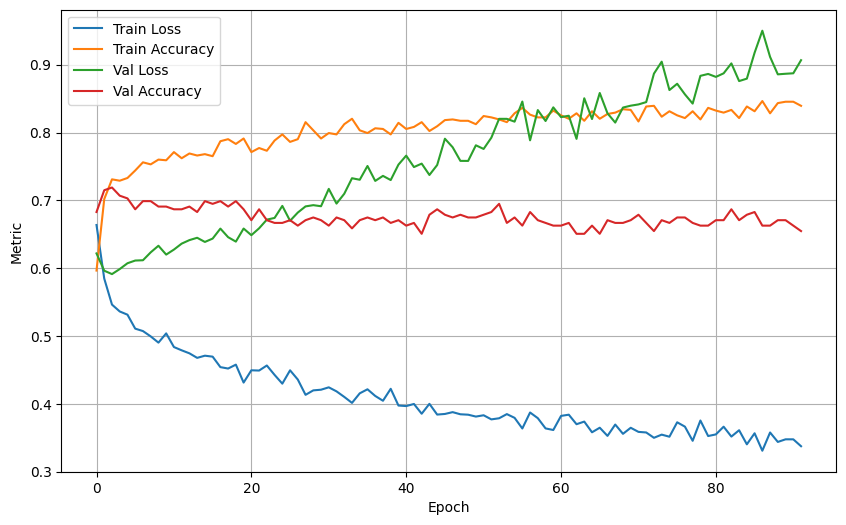

In [25]:
# Plotting 
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Metric')
#plt.title('Training & Validation Metrics')
plt.legend()
plt.grid(True)
plt.savefig('nn_metrics.png')
plt.show()

## Logit Model

### Hyperparameter Tuning and Fitting Model

In [28]:
## Step 1: Define model and pipeline
logreg = LogisticRegression(solver='saga', max_iter=1000, random_state=42)
lr_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('logit', logreg),
])

## Step 2: Define parameter distributions
lr_param_dist = {
    'logit__C': uniform(0.01, 10),
    'logit__penalty': ['l1', 'l2', 'elasticnet'],
    'logit__l1_ratio': [0.0, 0.5, 1.0],
}

## Step 3: Nested CV
lr_nested_scores_acc  = []
lr_nested_scores_auc  = []
lr_nested_scores_aupr = []
 
for train_idx, test_idx in outer_cv.split(X_scaled_df, y):
    X_tr, X_te = X_scaled_df.iloc[train_idx], X_scaled_df.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx],            y.iloc[test_idx]
 
    lr_inner = RandomizedSearchCV(
        lr_pipe, param_distributions=lr_param_dist,
        n_iter=20, scoring='accuracy', cv=5,
        random_state=42, n_jobs=-1, refit=True,
    )
    lr_inner.fit(X_tr, y_tr)
    y_prob = lr_inner.best_estimator_.predict_proba(X_te)[:, 1]
    y_pred = lr_inner.best_estimator_.predict(X_te)
    lr_nested_scores_acc.append((y_pred == y_te).mean())
    lr_nested_scores_auc.append(roc_auc_score(y_te, y_prob))
    lr_nested_scores_aupr.append(average_precision_score(y_te, y_prob))

In [29]:
print("\n=== Logistic Regression – nested 5-fold outer CV ===")
print(f"Accuracy : {np.mean(lr_nested_scores_acc):.3f} ± {np.std(lr_nested_scores_acc):.3f}")
print(f"ROC-AUC  : {np.mean(lr_nested_scores_auc):.3f} ± {np.std(lr_nested_scores_auc):.3f}")
print(f"PR-AUC   : {np.mean(lr_nested_scores_aupr):.3f} ± {np.std(lr_nested_scores_aupr):.3f}")
print("Best parameters:", lr_inner.best_params_) 


=== Logistic Regression – nested 5-fold outer CV ===
Accuracy : 0.717 ± 0.028
ROC-AUC  : 0.757 ± 0.030
PR-AUC   : 0.760 ± 0.033
Best parameters: {'logit__C': 0.47450412719997725, 'logit__l1_ratio': 1.0, 'logit__penalty': 'elasticnet'}


### Assessing Performance

In [31]:
# Step 3: Predict probabilities
y_prob_lr  = lr_inner.predict_proba(X_test)[:, 1]
y_pred = lr_inner.predict(X_test)

# Step 4: Print Scores
best_idx = lr_inner.best_index_
mean_cv_acc = lr_inner.cv_results_['mean_test_score'][best_idx]
std_cv_acc  = lr_inner.cv_results_['std_test_score'][best_idx] # SD for accuracy

print(f'Accuracy: {mean_cv_acc:.3f} '
      f'+/- {std_cv_acc:.3f}')
print(classification_report(y_test, y_pred))

Accuracy: 0.716 +/- 0.030
              precision    recall  f1-score   support

           0       0.71      0.67      0.69       254
           1       0.72      0.75      0.73       280

    accuracy                           0.71       534
   macro avg       0.71      0.71      0.71       534
weighted avg       0.71      0.71      0.71       534



In [32]:
# Step 6: ROC and AUC
prec_lr,  rec_lr,  _ = precision_recall_curve(y_test, y_prob_lr)
aupr_lr = average_precision_score(y_test, y_prob_lr)

#fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_pred_prob)
#lr_roc_score = roc_auc_score(y_test, y_pred_prob)

print(f'Area under the PR curve: {aupr_lr:.5f}')

# Step 8: Feature importance 
perm_lr = permutation_importance(
    lr_inner.best_estimator_, X_test, y_test,
    n_repeats=30, random_state=1, n_jobs=-1,
)
 
lr_sorted_idx = perm_lr.importances_mean.argsort()
mean_importances_lr = pd.Series(
    perm_lr.importances_mean[lr_sorted_idx],
    index=X.columns[lr_sorted_idx],
)

Area under the PR curve: 0.77207


# Non-Linear Interpretability Plots

### ROC and PR Curves

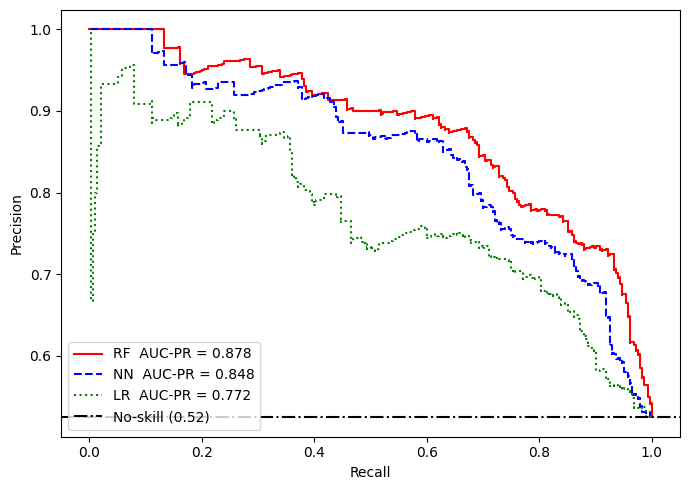

AUC-PR  RF: 0.878  |  NN: 0.848  |  LR: 0.772


In [35]:
## PR AUC Curves for multiple models
baseline = y_test.mean()   # proportion of positives
 
fig, ax = plt.subplots(figsize=(7, 5))
ax.step(rec_rf, prec_rf, where='post', color='red',
        label=f'RF  AUC-PR = {aupr_rf:.3f}')
ax.step(rec_nn, prec_nn, where='post', color='blue', linestyle='--',
        label=f'NN  AUC-PR = {aupr_nn:.3f}')
ax.step(rec_lr, prec_lr, where='post', color='green', linestyle=':',
        label=f'LR  AUC-PR = {aupr_lr:.3f}')
ax.axhline(y=baseline, color='k', linestyle='-.', label=f'No-skill ({baseline:.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
#ax.set_title('Precision–Recall Curves')
ax.legend(loc='lower left')
plt.tight_layout()
plt.savefig('all_pr_curve.png', dpi=150)
plt.show()
 
print(f"AUC-PR  RF: {aupr_rf:.3f}  |  NN: {aupr_nn:.3f}  |  LR: {aupr_lr:.3f}")

### Permutation Importance 

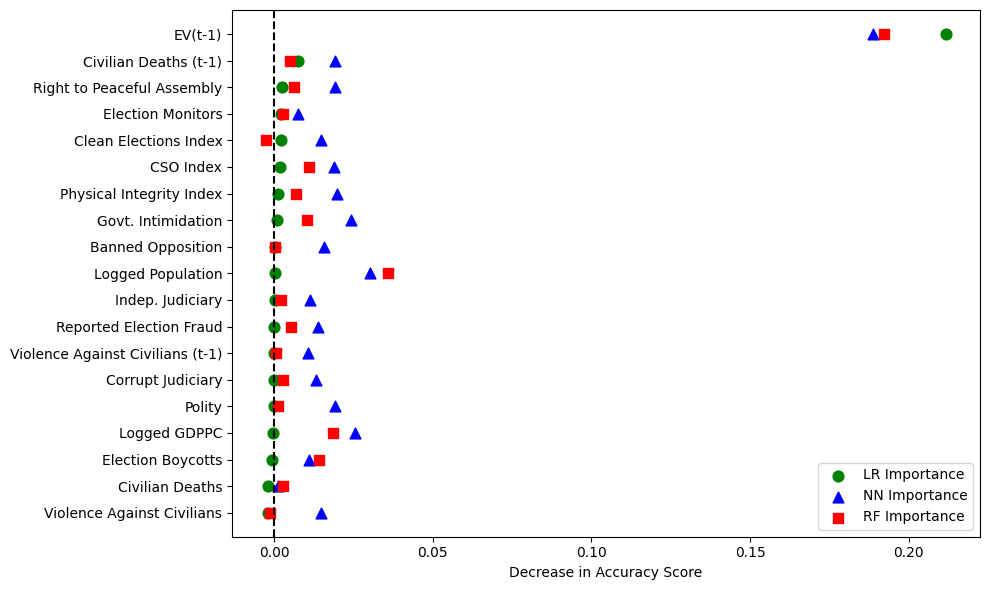

In [37]:
## Rename feature labels
feature_labels = {
    'lag_ev': 'EV(t-1)',
    'govt_intimidation': 'Govt. Intimidation',
    'civ_deaths':'Civilian Deaths', 
    'civ_violence':'Violence Against Civilians', 
    'indep_jud':'Indep. Judiciary', 
    'lag_civ_deaths':'Civilian Deaths (t-1)',
    'ethn_frac': "Ethnic Fract.",
    'elect_monitors': 'Election Monitors',
    'lag_civ_violence':'Violence Against Civilians (t-1)', 
    'elect_idx':'Clean Elections Index', 
    'opposition_ban':'Banned Opposition', 
    'peaceful_assemb': 'Right to Peaceful Assembly',
    'corrupt_jud':'Corrupt Judiciary', 
    'l_gdppc':'Logged GDPPC', 
    'reports_fraud':'Reported Election Fraud',
    'polity':'Polity', 
    'elect_boycott':'Election Boycotts',
    'l_pop':'Logged Population',
    'cso_idx': 'CSO Index',
    'phys_int': 'Physical Integrity Index'
}

lr_features_readable = mean_importances_lr.index.to_series().replace(feature_labels)
nn_features_readable = mean_importances_nn.index.to_series().replace(feature_labels)
rf_features_readable = mean_importances_rf.index.to_series().replace(feature_labels)

## Perm Importance for all 3 models
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(mean_importances_lr.values, lr_features_readable, 
           marker='o', s=60,
           color='green', label = 'LR Importance')  
ax.scatter(mean_importances_nn.values, nn_features_readable, 
           marker='^', s=60,
           color='blue', label = 'NN Importance')
ax.scatter(mean_importances_rf.values, rf_features_readable, 
           marker='s', s=60,
           color='red', label = 'RF Importance')
ax.axvline(x=0, color='k', linestyle='--')
ax.set_xlabel("Decrease in Accuracy Score")
ax.set_ylabel("")
ax.set_title("")
plt.tight_layout()
plt.legend(loc = 'lower right')
plt.savefig('all_perm.png')
plt.show()

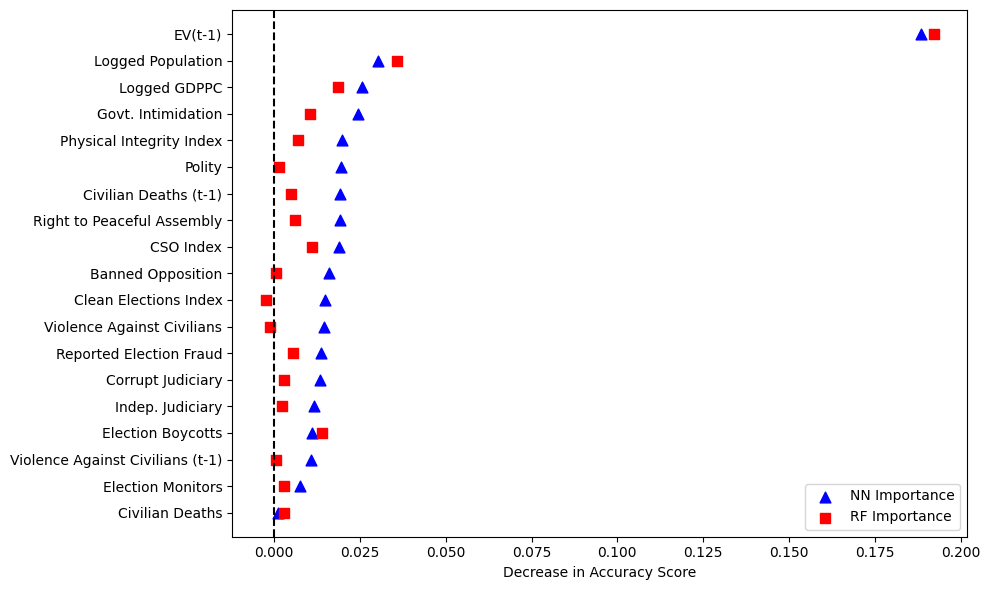

In [39]:
## Perm Importance for ML models
fig, ax = plt.subplots(figsize=(10, 6)) 
ax.scatter(mean_importances_nn.values, nn_features_readable, 
           marker='^', s=60,
           color='blue', label = 'NN Importance')
ax.scatter(mean_importances_rf.values, rf_features_readable, 
           marker='s', s=60,
           color='red', label = 'RF Importance')
ax.axvline(x=0, color='k', linestyle='--')
ax.set_xlabel("Decrease in Accuracy Score")
ax.set_ylabel("")
ax.set_title("")
plt.tight_layout()
plt.legend(loc = 'lower right')
plt.savefig('ML_perm.png')
plt.show()

## Partial Dependence Plots

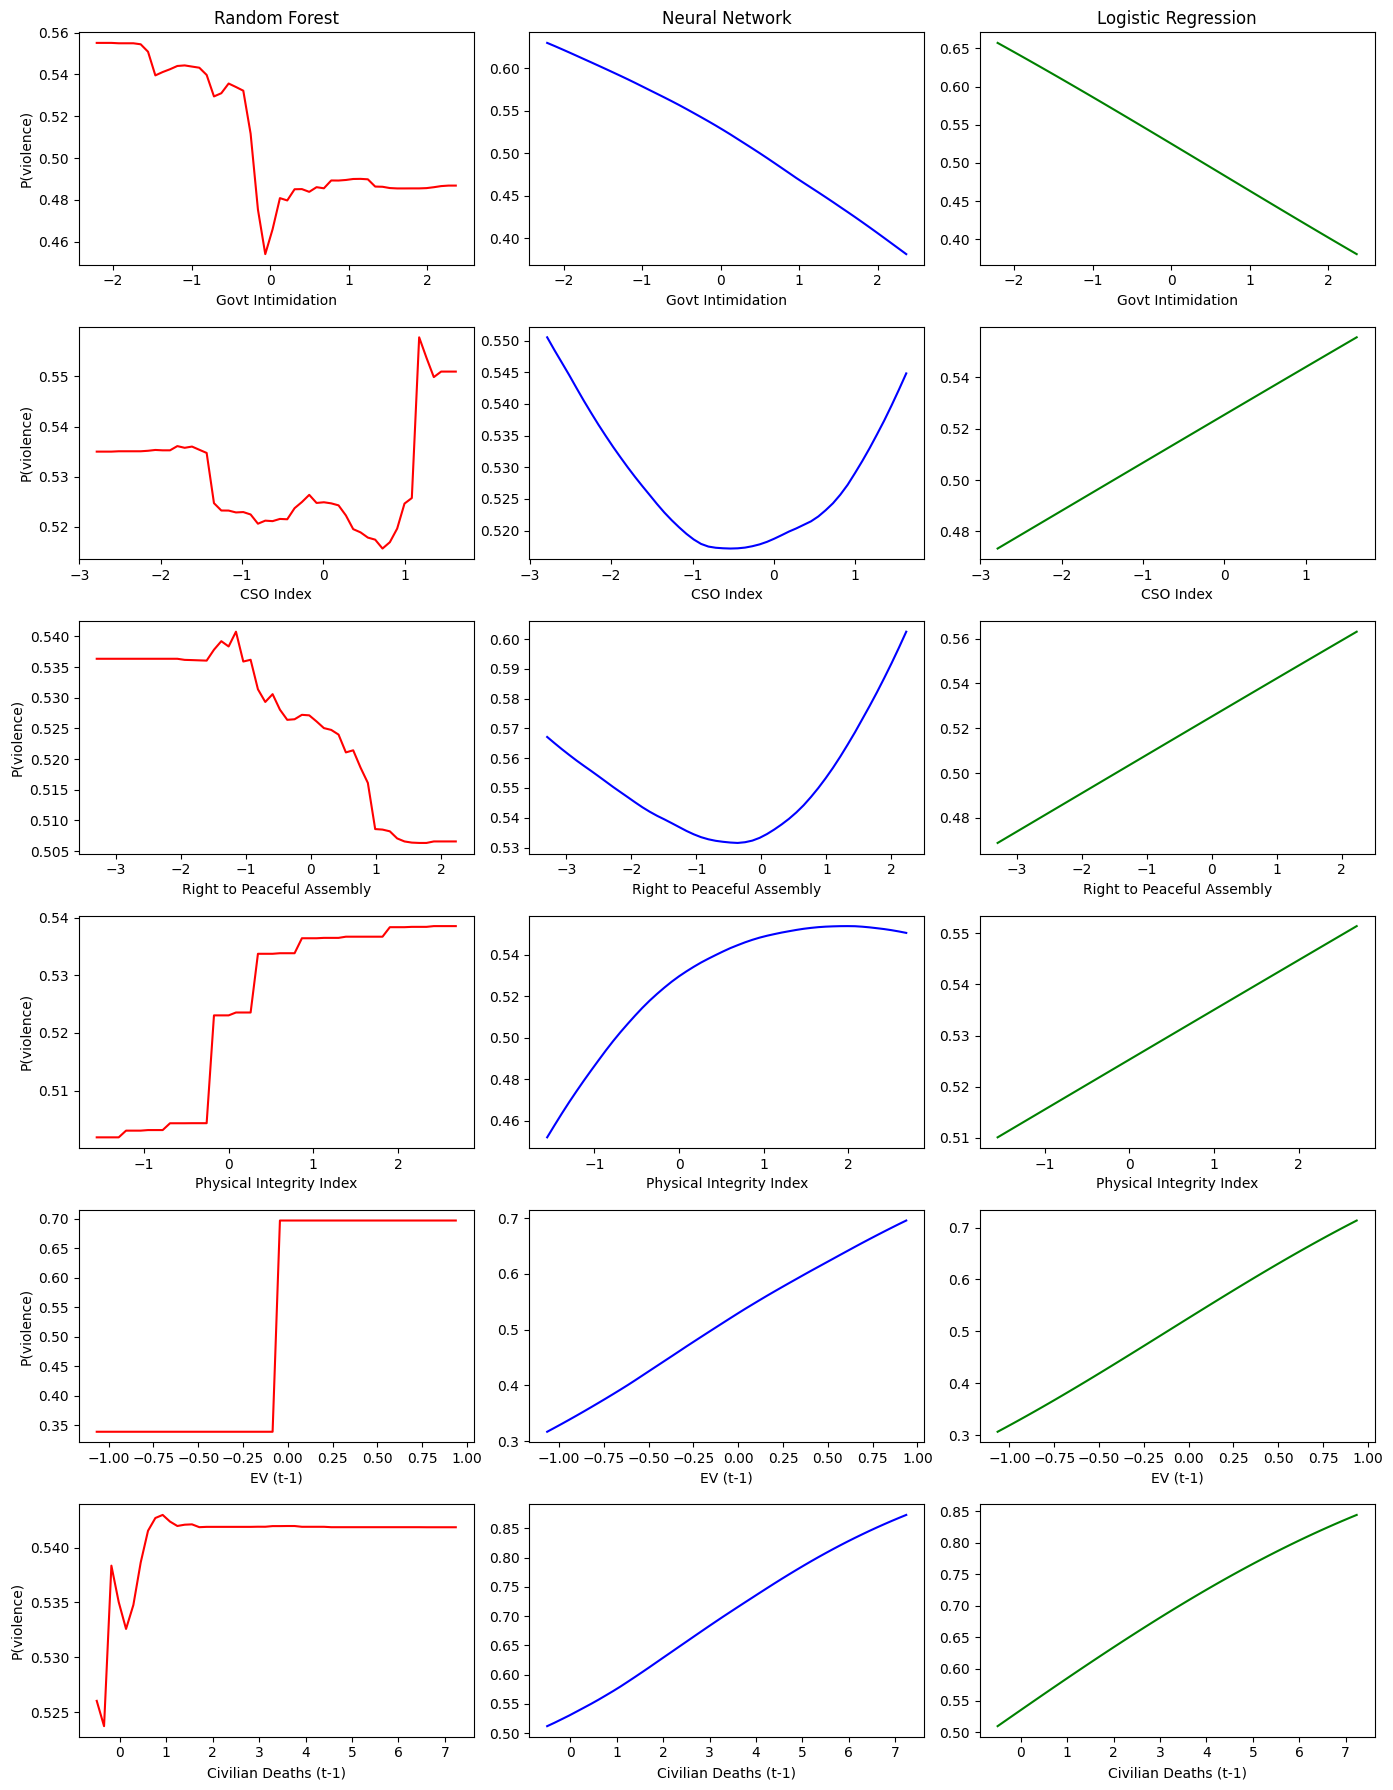

In [41]:
## Partial Dependence Plot
# PDPs show the marginal effect of each feature on the predicted probability
# of electoral violence, averaged over all other features. 
# Plot the five features with the highest importance across all models for
# a direct visual comparison.

# Features and labels
features_to_plot = ['govt_intimidation', 'cso_idx', 
                    'peaceful_assemb', 'phys_int',
                    'lag_ev', 'lag_civ_deaths']

feature_labels = {
    'govt_intimidation': 'Govt Intimidation',
    'cso_idx': 'CSO Index',
    'peaceful_assemb': 'Right to Peaceful Assembly',
    'phys_int': 'Physical Integrity Index',
    'lag_ev': 'EV (t-1)',
    'lag_civ_deaths': 'Civilian Deaths (t-1)'
}

# Model Aesthetics
models  = [rf_inner, nn_inner, lr_inner]
titles  = ['Random Forest', 'Neural Network', 'Logistic Regression']
colours = ['red', 'blue', 'green']

fig, axes = plt.subplots(len(features_to_plot), 3,
                         figsize=(14, 3 * len(features_to_plot)),
                         sharey=False)

grid_resolution = 50

# PLOT!
for col, (model, title, colour) in enumerate(zip(models, titles, colours)):
    for row, feat in enumerate(features_to_plot):
        ax = axes[row, col]

        # Create grid of values for the feature
        X_temp = X_train.copy()
        values = np.linspace(X_temp[feat].min(), X_temp[feat].max(), grid_resolution)
        avg_preds = []

        # Manual PDP for all models
        for val in values:
            X_temp[feat] = val
            if title == 'Neural Network':
                preds = model.predict_proba(X_temp)[:,1]
            else:
                preds = model.predict_proba(X_temp)[:,1]  # RF and LR output predict_proba
            avg_preds.append(np.mean(preds))

        # Plot
        ax.plot(values, avg_preds, color=colour)
        ax.set_ylabel('P(violence)' if col == 0 else '')
        ax.set_xlabel(feature_labels.get(feat, feat))
        if row == 0:
            ax.set_title(title, fontsize=12)

#plt.suptitle('Partial Dependence Plots', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('pdp_all.png')
plt.show()

## SHAP Values
https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html
https://www.aidancooper.co.uk/a-non-technical-guide-to-interpreting-shap-analyses/

### Random Forest

In [ ]:
## Compute the SHAP values for the RF model
X100 = shap.utils.sample(X, 100) 
explainer = shap.Explainer(rf_inner.predict, X100)
shap_values = explainer(X)
sample_ind = 20

In [57]:
## Plots
shap.plots.bar(shap_values[sample_ind], show=False)
plt.savefig("shap_bar_rf.png", bbox_inches="tight", dpi=300)
plt.close()

### Neural Network

In [63]:
## Compute the SHAP values for the NN model
X100 = shap.utils.sample(X, 100) 
explainer = shap.Explainer(nn_inner.predict, X100)
shap_values = explainer(X)
sample_ind = 20

PermutationExplainer explainer: 1780it [18:05,  1.62it/s]                       


In [70]:
## Plots
shap.plots.bar(shap_values[sample_ind], show=False)
plt.savefig("shap_bar_nn.png", bbox_inches="tight", dpi=300)
plt.close()

### Logit

In [72]:
## Compute the SHAP values for the LR model
X100 = shap.utils.sample(X, 100) 
explainer = shap.Explainer(lr_inner.predict, X100)
shap_values = explainer(X)
sample_ind = 20

PermutationExplainer explainer: 1780it [01:09, 21.43it/s]                       


In [76]:
## Plots
shap.plots.bar(shap_values[sample_ind], show=False)
plt.savefig("shap_bar_lr.png", bbox_inches="tight", dpi=300)
plt.close()

## Nested CV Summary Table

In [78]:
summary = pd.DataFrame({
    'Model':    ['Random Forest', 'Neural Network', 'Logistic Regression'],
    'Accuracy': [f"{np.mean(rf_nested_scores_acc):.3f} ± {np.std(rf_nested_scores_acc):.3f}",
                 f"{np.mean(nn_nested_scores_acc):.3f} ± {np.std(nn_nested_scores_acc):.3f}",
                 f"{np.mean(lr_nested_scores_acc):.3f} ± {np.std(lr_nested_scores_acc):.3f}"],
    'ROC-AUC':  [f"{np.mean(rf_nested_scores_auc):.3f} ± {np.std(rf_nested_scores_auc):.3f}",
                 f"{np.mean(nn_nested_scores_auc):.3f} ± {np.std(nn_nested_scores_auc):.3f}",
                 f"{np.mean(lr_nested_scores_auc):.3f} ± {np.std(lr_nested_scores_auc):.3f}"],
    'PR-AUC':   [f"{np.mean(rf_nested_scores_aupr):.3f} ± {np.std(rf_nested_scores_aupr):.3f}",
                 f"{np.mean(nn_nested_scores_aupr):.3f} ± {np.std(nn_nested_scores_aupr):.3f}",
                 f"{np.mean(lr_nested_scores_aupr):.3f} ± {np.std(lr_nested_scores_aupr):.3f}"],
})
print(summary.to_string(index=False))

              Model      Accuracy       ROC-AUC        PR-AUC
      Random Forest 0.741 ± 0.035 0.808 ± 0.029 0.814 ± 0.025
     Neural Network 0.722 ± 0.029 0.792 ± 0.028 0.791 ± 0.033
Logistic Regression 0.717 ± 0.028 0.757 ± 0.030 0.760 ± 0.033
